In [1]:
import os
from google.colab import userdata

In [2]:
gemini_key = userdata.get('Gemini')
os.environ['GOOGLE_API_KEY'] = gemini_key
os.environ['GEMINI_API_KEY'] = gemini_key

In [3]:
openai_key = userdata.get('OpenAI')
os.environ['OPENAI_API_KEY'] = openai_key

In [4]:
mistral_key = userdata.get('Mistral')
os.environ['MISTRALAI_API_KEY'] = mistral_key

In [5]:
groq_key = userdata.get('Groq')
os.environ['GROQ_API_KEY'] = groq_key

In [6]:
try:
  import chromadb
except:
  !pip install -qU chromadb
  import chromadb

In [7]:
try:
    import langchain_core
except:
  !pip install -qU langchain-core
  import langchain_core

In [8]:
try:
    import langchain_community
except:
    !pip install -qU langchain-community
    import langchain_community

In [9]:
try:
  !pip install -qU openai
  !pip install -qU google-genai
  !pip install -qU mistralai

  import langchain
  from langchain_openai import ChatOpenAI
  from langchain_google_genai import ChatGoogleGenerativeAI
  from langchain_groq import ChatGroq
  from langchain_mistralai.chat_models import ChatMistralAI
  from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFacePipeline
except:
  !pip install -qU langchain_chroma
  !pip install grandalf
  !pip install -U langchain
  import langchain

  !pip install -qU langchain-openai
  from langchain_openai import ChatOpenAI
  !pip install -qU langchain-google-genai
  from langchain_google_genai import ChatGoogleGenerativeAI
  !pip install -qU langchain-groq
  from langchain_groq import ChatGroq
  !pip install -qU langchain-mistralai
  from langchain_mistralai.chat_models import ChatMistralAI
  !pip install -qU  langchain-huggingface
  from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.40.0 requires opentelemetry-api==1.40.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.40.0 requires opentelemetry-semantic-conventions==0.61b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-exporter-otlp-proto-common==1.38.0, but you have opentelemetry-exporter-otlp-proto-common 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-proto==1.38.0, but you have opentelemetry-proto 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentel

## Retrieval Augmented Generation (RAG) - LLMs + Custom Data

From `weivate.io`

**Retrieval augmented generation is a powerful technique that retrieves relevant data to provide to large language models (LLMs) as context, along with the task prompt. It is also called RAG, generative search, or in-context learning in some cases.**

### Why use RAG?

From `weivate.io`

LLM are incredibly powerful, but can suffer from two important limitations. These limitation are that:

- They can confidently produce incorrect, or outdated, information (also called 'hallucination'); and
- They might simply not be trained on the information you need.
RAG remedies this problem with a two-step process.

  - The first step is to retrieve relevant data through a query.
  - Then, in the second step, the LLM is prompted with a combination of the retrieve data with a user-provided query.

This provides in-context learning for the LLM, which causes it to use the relevant and up-to-date data rather than rely on recall from its training, or even worse, hallucinated outputs

### Introduction

**What are the uses of LLMs?**
- **Powerful state-of-the-art models** trained on **vast amounts of data**
- Capable of **answering questions** across **various topics**
- **Rapidly evolving** with **better, more knowledgeable versions**

**What are the Limitations of LLM?**
- **Training is expensive** (time + money)
- **Knowledge has a cutoff date**
- **Cannot answer questions** about **proprietary/custom data**

**How to address the limitations of LLM?**

Combine LLMs with Custom Data, enables LLMs to:
- **Analyze and summarize** results
- **Tag files** automatically  
- **Perform question answering** on private data

**What are the methods to combine LLMs with custom data?**

| Method | Description | Implementation |
|--------|-------------|----------------|
| **1. Prompting** | **Fastest approach**: System messages, few-shot examples, chat history | **Quick & easy** - no training needed |
| **2. Fine-tuning** | **Retraining** pre-trained model on custom data | **High control** but resource-heavy |
| **3. RAG** | **Retrieve relevant docs** → **Augment LLM prompt** | **Scalable** for large datasets |

#### Prompting

**Quickest implementation** using direct feeding of data through:

```
- System messages (set behavior)
- Few-shot prompting (examples)  
- Chat history (context)
```
**Pros**: Immediate (quick and easy to implement), no training  
**Cons**: Limited by context window, Time inefficient, More tokens are consumed

#### Fine-tuning

**Directly modifies** the pre-trained model weights.

**Advantages**:
- Trained on **vast amounts of custom data**
- **Good quality outputs**
- **Requires less context**
- **Shorter prompts needed**
- **Faster response times**

**Disadvantages**:
- **High time + computational cost**
- Needs **substantial dataset**
- Requires **ML/DL expertise**

#### RAG (Retrieval Augmented Generation)

**Most scalable** for large proprietary datasets.

Store large amount of data **embeddings** in database → **retrieve only relevant chunks** → answer the user query with full context.

**Pipeline**:
```
1. Document Loading
2. Document Splitting  
3. Document Embedding
4. Document Storing (vector DB)
5. Document Retrieval (semantic search)
6. Augmented Generation (LLM + retrieved context)
```

- **Prompting** = Fast prototyping
- **Fine-tuning** = Maximum control  
- **RAG** = Production-scale custom data

### RAG Pipeline: 3 Core Componenets

**RAG (Retrieval Augmented Generation)** breaks down into **three distinct phases**:

```
1. INDEXING → Preparing the data and storing it in a specialized database.
2. RETRIEVAL → Retrieving only the documents most relevant to a user's request.  
3. GENERATION → Taking the user request with the retrieved documents and employing an LLM to produce a context-aware response.
```

#### 1. INDEXING (Data Preparation)

Converts raw documents → searchable vector database


| Step | Purpose | LangChain Component |
|------|---------|-------------------|
| **Load Data** | Convert various formats → LangChain `Document` objects | `TextLoader`, `PDFLoader`, `WebBaseLoader` |
| **Split Data** | Break into **chunks** (fit LLM context window) | `RecursiveCharacterTextSplitter`, `TokenTextSplitter` |
| **Embed Data** | **Vectorize** text → capture **semantic meaning** | `OpenAIEmbeddings`, `HuggingFaceEmbeddings` |
| **Store Data** | Save **vectors** in **vector store** | `Chroma`, `FAISS`, `Pinecone`, `Weaviate` |

Document chunks → Vector embeddings → Persistent vector store

#### 2. RETRIEVAL (Semantic Search)

Process a user query by querying the document database to retrieve the **most relevant and diverse data segments**.

- **Diverse segments** ensure that even when selecting semantically similar chunks to the query, every piece provides **unique and meaningful new information**.

```
User Query → Embed → Similarity Search → Top-K Relevant Documents
```

**Process**:
1. **Embed user query** (same embedding model as indexing)
2. **Search vector store** for **most similar** document chunks
3. **Retrieve top-K** documents (usually 3-10)

**Only processes relevant 1-5%** of total data.

#### 3. GENERATION (Context-Aware Response)

The user query and retreived documents are fed to a language model as a prompt. The model then constructs a response and send it back to user.

A technique where **retrieved documents are merged with user queries** before being passed to a large language model, producing responses that are contextually relevant and coherent.

```
Prompt Template:
"Answer using ONLY this context: {retrieved_docs}
Question: {user_query}
Answer:"

LLM → Context-aware response
```

**Flow**:
```
User Query + Retrieved Docs → Augmented Prompt → LLM → Final Answer
```

RAG involves prompting the most relevant part of data rather than the huge dataset. It avoids the need of feeding of entire data as a prompt.

Disadvantages of RAG
- Increased latency of the response, due to retrieving information
- The quality of the retrieved documents influences the model's response

| Issue | Impact | Mitigation |
|-------|--------|------------|
| **Increased Latency** | Retrieval + generation (200-800ms) | **Async retrieval**, **caching**, **smaller chunks** |
| **Retrieval Quality** | Bad docs → bad answers | **Hybrid search**, **reranking**, **better embeddings** |

#### Summary

| Approach | Data Usage | Latency | Scalability |
|----------|------------|---------|-------------|
| **Full Prompt** | 100% dataset | Fast | Poor |
| **Fine-tuning** | Custom model | Fastest | Expensive |
| **RAG** | **1-5% relevant** | Medium | **Best** |

**RAG = Optimal balance** for production custom data applications!

### Document Loading

**Document Loading** converts **diverse data formats** into a **uniform LangChain `Document` structure**, enabling consistent processing across all RAG pipeline stages.

**Purpose**
```
Raw Files (PDF, HTML, JSON, TXT, etc.)
    ↓ Uniform Processing
A list of LangChain Document Objects
    ↓ Identical Handling
Split → Embed → Store → Retrieve
```

**What is a `Document` Object?**

Document is a class in langchain used to store piece of text and its metadata such as Page Number, Document Title and Document Subtitle etc

```python
Document = {
    "page_content": "The actual text content",
    "metadata": {
        "source": "file.pdf",
        "page": 3,
        "title": "Annual Report 2025",
        "chunk_id": 42
    }
}
```

**Stores**: Text content + **rich metadata** (page number, source file, title, etc.)

**Supported Data Sources**

| **Local Files** | **Web/Remote** | **APIs/Storage** |
|-----------------|----------------|------------------|
| PDF, DOCX, TXT | HTML, Markdown | Google Drive |
| CSV, JSON, YAML | Sitemaps | Notion |
| EPUB, PowerPoint | RSS Feeds | SharePoint |
| Audio/Video (transcription) | ArXiv papers | Confluence |

**Key Loader Classes**

| Loader | Formats | Use Case |
|--------|---------|----------|
| `PDFLoader` | PDF | Research papers, reports |
| `WebBaseLoader` | HTML | Websites, blogs |
| `TextLoader` | TXT, MD | Plain text, notebooks |
| `UnstructuredLoader` | DOCX, PPT | Office documents |
| `CSVLoader` | CSV | Tabular data |
| `JSONLoader` | JSON | API responses |

In [ ]:
llm = ChatOpenAI(
    model = 'gpt-5-nano'
)
llm

ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7f14c7cd0080>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7f14c7e86300>, root_client=<openai.OpenAI object at 0x7f14c7e86960>, root_async_client=<openai.AsyncOpenAI object at 0x7f14c7b9f590>, model_name='gpt-5-nano', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

##### Loading a .txt file

In [ ]:
from langchain_community.document_loaders import TextLoader

In [ ]:
loader = TextLoader('/content/DL_Questions.txt')
loader

In [ ]:
loaded_data = loader.load()
loaded_data

[Document(metadata={'source': '/content/DL_Questions.txt'}, page_content='Deep learning Interview questions\nQ1 – What is Deep Learning?\nQ2 – What is Deep Learning?\nQ3 – What is a Neural Network?\nQ4 – Explain the concept of a neuron in Deep Learning.\nQ5 – Explain architecture of Neural Networks in simple way\nQ6 – What is an activation function in a Neural Network?\nQ7 – Name few popular activation functions and describe them\nQ8 – What happens if you do not use any activation functions in a NN?\nQ9 – Describe how training of basic Neural Networks works\nQ10 – What is Gradient Descent?\nQ11 – What is the function of an optimizer in Deep Learning?\nQ12 – What is backpropagation, and why is it important in Deep Learning?\nQ13 – How is backpropagation different from gradient descent?\nQ14 – Describe what Vanishing Gradient Problem is and it’s impact on NN\nQ15 – Describe what Exploding Gradients Problem is and it’s impact on NN\nQ16 – There is a neuron results in a large error in back

In [ ]:
from copy import copy, deepcopy

In [ ]:
# COpy the data to new variable
data_copy = deepcopy(loaded_data)

In [ ]:
# Clean the data
' '.join(data_copy[0].page_content.split())

'Deep learning Interview questions Q1 – What is Deep Learning? Q2 – What is Deep Learning? Q3 – What is a Neural Network? Q4 – Explain the concept of a neuron in Deep Learning. Q5 – Explain architecture of Neural Networks in simple way Q6 – What is an activation function in a Neural Network? Q7 – Name few popular activation functions and describe them Q8 – What happens if you do not use any activation functions in a NN? Q9 – Describe how training of basic Neural Networks works Q10 – What is Gradient Descent? Q11 – What is the function of an optimizer in Deep Learning? Q12 – What is backpropagation, and why is it important in Deep Learning? Q13 – How is backpropagation different from gradient descent? Q14 – Describe what Vanishing Gradient Problem is and it’s impact on NN Q15 – Describe what Exploding Gradients Problem is and it’s impact on NN Q16 – There is a neuron results in a large error in backpropagation. Reason? Q17 – What do you understand by a computational graph? Q18 – What is

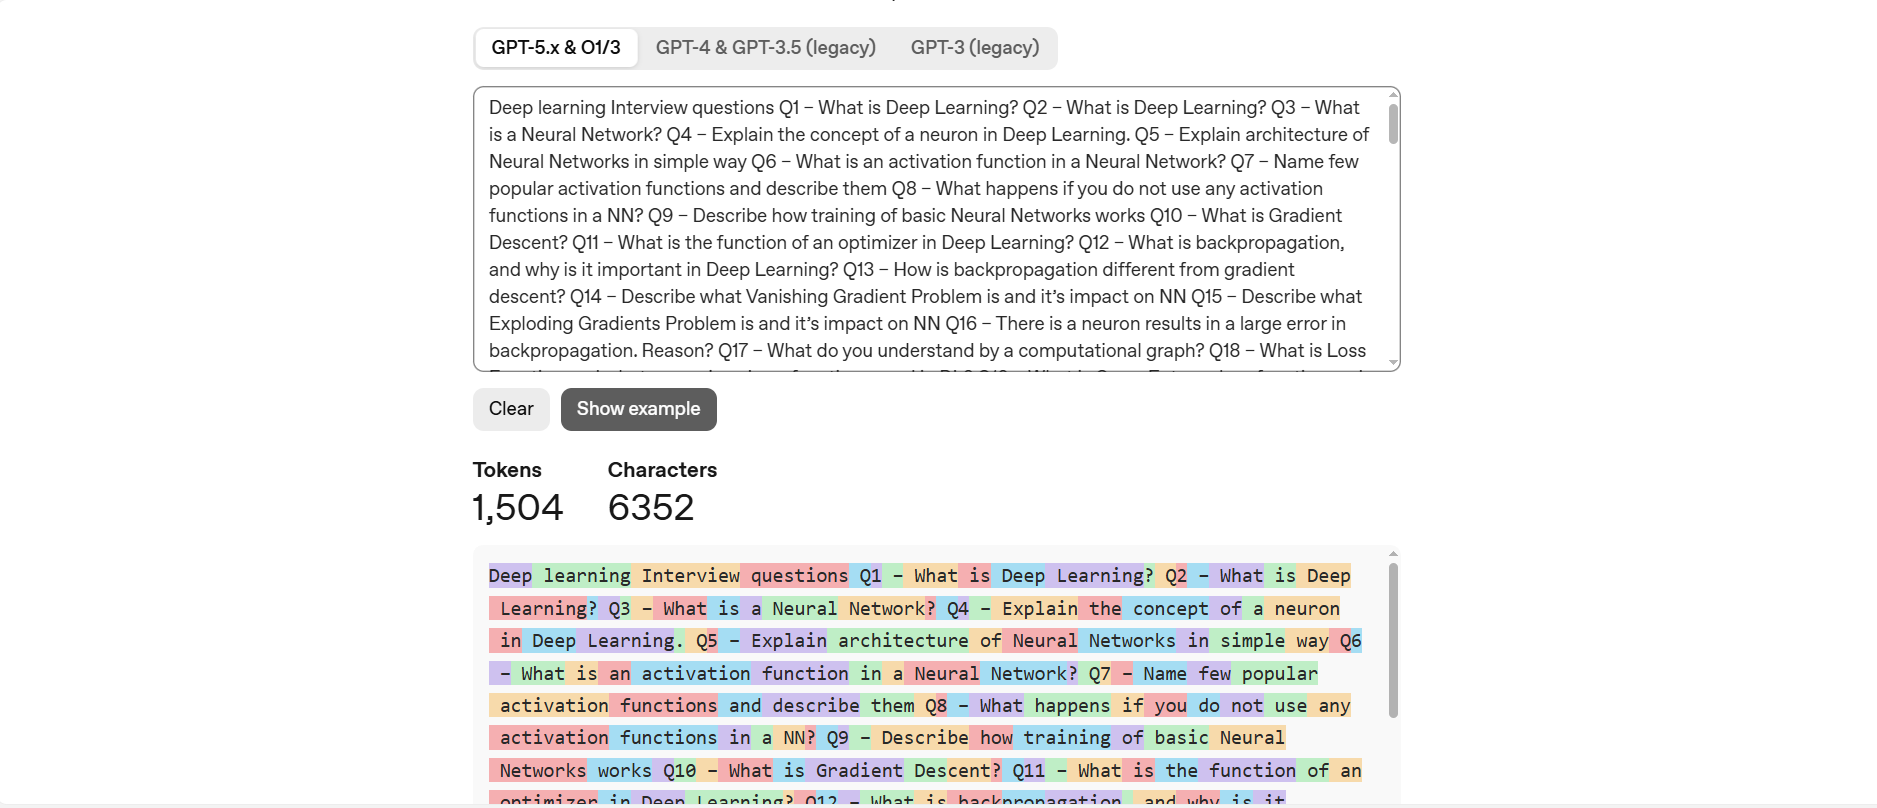

##### Loading a .docx file

In [ ]:
!pip install docx2txt

In [ ]:
from langchain_community.document_loaders import Docx2txtLoader

In [ ]:
loader = Docx2txtLoader(r'/content/Production-Ready GenAI Chatbot Project.docx')
loader

In [ ]:
loaded_data = loader.load()
loaded_data

[Document(metadata={'source': '/content/Production-Ready GenAI Chatbot Project.docx'}, page_content='Production-Ready GenAI Chatbot Project \n\n\n\n1. Project Title\n\nBuilding a Production-Ready Domain-Specific Chatbot using Gemini GenAI API\n\n2. Project Overview\n\nThis project focuses on designing, developing, and deploying a production-ready chatbot application powered by the Google Gemini GenAI API.\n\nThe chatbot must be built for a specific domain and deployed in a cloud environment following real-world AI engineering standards.\n\nThe goal is to move beyond a basic demo and implement a scalable, secure, and well-structured GenAI application.\n\n3. Domain Selection\n\nYou may choose any of your interested domain or one domain from the following:\n\nE-commerce Chatbot\n\nBlog Assistant Chatbot\n\nMental Health Support Chatbot\n\nNews Chatbot\n\nCareer Advisor Chatbot\n\nFinancial Advisor Chatbot\n\nThe chatbot must provide domain-specific, structured, and intelligent responses.\

In [ ]:
loaded_data[0].page_content

'Production-Ready GenAI Chatbot Project \n\n\n\n1. Project Title\n\nBuilding a Production-Ready Domain-Specific Chatbot using Gemini GenAI API\n\n2. Project Overview\n\nThis project focuses on designing, developing, and deploying a production-ready chatbot application powered by the Google Gemini GenAI API.\n\nThe chatbot must be built for a specific domain and deployed in a cloud environment following real-world AI engineering standards.\n\nThe goal is to move beyond a basic demo and implement a scalable, secure, and well-structured GenAI application.\n\n3. Domain Selection\n\nYou may choose any of your interested domain or one domain from the following:\n\nE-commerce Chatbot\n\nBlog Assistant Chatbot\n\nMental Health Support Chatbot\n\nNews Chatbot\n\nCareer Advisor Chatbot\n\nFinancial Advisor Chatbot\n\nThe chatbot must provide domain-specific, structured, and intelligent responses.\n\n\n\n\n\n\n4. Technical Requirements\n\nThe solution must follow production-grade AI architecture 

##### Loading a CSV file

In [ ]:
from langchain_community.document_loaders.csv_loader import CSVLoader

In [ ]:
loader = CSVLoader(r'/content/Sample_Sentiment_Analysis_Dataset.csv')
loader

In [ ]:
csv_data = loader.load()
csv_data

[Document(metadata={'source': '/content/Sample_Sentiment_Analysis_Dataset.csv', 'row': 0}, page_content='ItemID: 1\nSentiment: 0\nSentimentText: is so sad for my APL friend.............'),
 Document(metadata={'source': '/content/Sample_Sentiment_Analysis_Dataset.csv', 'row': 1}, page_content='ItemID: 2\nSentiment: 0\nSentimentText: I missed the New Moon trailer...'),
 Document(metadata={'source': '/content/Sample_Sentiment_Analysis_Dataset.csv', 'row': 2}, page_content='ItemID: 3\nSentiment: 1\nSentimentText: omg its already 7:30 :O'),
 Document(metadata={'source': '/content/Sample_Sentiment_Analysis_Dataset.csv', 'row': 3}, page_content="ItemID: 4\nSentiment: 0\nSentimentText: .. Omgaga. Im sooo  im gunna CRy. I've been at this dentist since 11.. I was suposed 2 just get a crown put on (30mins)..."),
 Document(metadata={'source': '/content/Sample_Sentiment_Analysis_Dataset.csv', 'row': 4}, page_content='ItemID: 5\nSentiment: 0\nSentimentText: i think mi bf is cheating on me!!!       T

##### Loading a .pdf file

In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.2/332.2 kB 5.4 MB/s eta 0:00:00


In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
loader = PyPDFLoader('/content/GenAI_Internship_Roadmap.pdf')
loader

In [ ]:
loaded_data = loader.load()
loaded_data

[Document(metadata={'producer': 'PyPDF', 'creator': 'Google Sheets', 'creationdate': '', 'title': 'GenAI_Internship_Roadmap_JAN_2026', 'source': '/content/GenAI_Internship_Roadmap.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.\nWeek 2: Generative AI Basics – API-Powered Ch

##### Loading an .html file

In [ ]:
!pip install beautifulsoup4

In [ ]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

In [ ]:
loader = WebBaseLoader(
    web_paths=("https://nasa.github.io/oceandata-notebooks/notebooks/oci/ml_cloud_mask.html",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("tex2jax_ignore mathjax_ignore")
        )
    ),
)
docs = loader.load()
docs

[Document(metadata={'source': 'https://nasa.github.io/oceandata-notebooks/notebooks/oci/ml_cloud_mask.html'}, page_content='\nMachine Learning Tutorial#\nAuthor(s): Sean Foley (NASA, MSU)\nLast updated: August 3, 2025\n\nThe following notebooks are prerequisites for this tutorial:\n\nData Access\n\nNOTE: This notebook will download a cloud mask dataset. Update CLDMASK_PATH if you would like the download and extracted archive to be persisted after running this notebook.\n\n\nSummary#\nThis tutorial will walk you through a simple machine learning pipeline. We will apply some basic supervised learning techniques to the task of cloud masking in PACE data.\n\n\nLearning Objectives#\nAt the end of this notebook you will know:\n\nHow to construct a simple machine learning dataset in Pytorch\nThe meaning of training, validation, and test sets\nHow to construct a simple neural network in Pytorch\nHow the backpropagation algorithm works\nHow to construct a training loop in Pytorch\n\nStretch goa

In [ ]:
docs[0].page_content

'\nMachine Learning Tutorial#\nAuthor(s): Sean Foley (NASA, MSU)\nLast updated: August 3, 2025\n\nThe following notebooks are prerequisites for this tutorial:\n\nData Access\n\nNOTE: This notebook will download a cloud mask dataset. Update CLDMASK_PATH if you would like the download and extracted archive to be persisted after running this notebook.\n\n\nSummary#\nThis tutorial will walk you through a simple machine learning pipeline. We will apply some basic supervised learning techniques to the task of cloud masking in PACE data.\n\n\nLearning Objectives#\nAt the end of this notebook you will know:\n\nHow to construct a simple machine learning dataset in Pytorch\nThe meaning of training, validation, and test sets\nHow to construct a simple neural network in Pytorch\nHow the backpropagation algorithm works\nHow to construct a training loop in Pytorch\n\nStretch goals:\n\nHow to use a GPU to speed up training\nHow to use a convolutional neural network to process images better and faster

##### Loading a Wikipedia page

In [ ]:
pip install -qU langchain_community wikipedia

  Preparing metadata (setup.py) ... done


In [ ]:
from langchain_community.document_loaders import WikipediaLoader

In [ ]:
name = 'Langchain'
loader = WikipediaLoader(query=name, load_max_docs=1)
loader

In [ ]:
loader.load()

[Document(metadata={'title': 'LangChain', 'summary': "LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.", 'source': 'https://en.wikipedia.org/wiki/LangChain'}, page_content='LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain\'s use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.\n\n\n== History ==\nLangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, LangChain had incorporated and the new startup ra

In [ ]:
loader.load()[0].page_content

'LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain\'s use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.\n\n\n== History ==\nLangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, LangChain had incorporated and the new startup raised over $20 million in funding at a valuation of at least $200 million from venture firm Sequoia Capital, a week after announcing a $10 million seed investment from Benchmark.\nIn the third quarter of 2023, the LangChain Expression Language (LCEL) was introduced, which provides a declarative way to define chains of actions.\nIn October 2023 LangChain introduced LangServe, a deployment tool to host LCEL code as a production-ready API.\nIn F

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate

In [ ]:
template = "Answer the {question}, here is some extra {context}"
template

'Answer the {question}, here is some extra {context}'

In [ ]:
chat_template = ChatPromptTemplate.from_messages(
    [
        HumanMessagePromptTemplate.from_template(template)
    ]
)
chat_template

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the {question}, here is some extra {context}'), additional_kwargs={})])

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
chain = chat_template | llm | StrOutputParser()
chain

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the {question}, here is some extra {context}'), additional_kwargs={})])
| ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7f14c7cd0080>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7f14c7e86300>, root_client=<openai

In [ ]:
response = chain.invoke({
    'question': 'Who invested recently in langchain?',
    'context': loader.load()[0].page_content
})
response

'Sequoia Capital. They led LangChain’s February 2024 Series A of about $25 million, which is the most recent investment. Previously, Benchmark Seed invested $10 million in April 2023, and Sequoia Capital also led a roughly $20 million round in April 2023.'

**Motivation for document splitting**

The initial list of document objects presents several critical issues:

1. **Unrestricted document size**: There is **no limit on the amount** of content each document can contain, while **large language models have strict restrictions on the maximum content** length they can process.

2. **Excessive cost from large documents**: Even when content fits within the model's context limit, **consistently passing large documents leads to unnecessary token consumption**, which significantly increases application costs.

**Solution**: We need a mechanism called **document splitting** to divide these large document objects into smaller, manageable chunks suitable for LLM processing.


### Document splitting

**Document splitting** research demonstrates that language models perform significantly better when provided with focused document chunks covering a single topic, rather than large texts spanning multiple subjects.

- We need a splitting mechanism that achieves two objectives:
  - reducing document length to fit LLM context windows while ensuring each chunk centers around **one coherent topic**.
  - each chunk contains meaningful information and fits the context window limit of the chat model.



LangChain provides several specialized splitters, including **CharacterTextSplitter** for basic text division and **MarkdownHeaderTextSplitter** for structure-preserving splits.

To identify semantically similar documents during retrieval, **document embeddings** convert text chunks into vector representations that capture their semantic meaning.

##### Character Splitter

Splits text using **double newlines (`\n\n`)** as the delimiter by default.

- **Character-based**: Measures chunk length by number of characters
- **Simple**: Finds `\n\n` → splits there
- **Default**: Natural paragraph breaks

**RAG benefit**: Breaks large docs into **manageable chunks** for better retrieval accuracy.

**Example**:
```
Text block 1\n\nText block 2\n\nText block 3
↓ splits into:
["Text block 1", "Text block 2", "Text block 3"]
```

In [ ]:
from langchain_community.document_loaders import TextLoader

In [ ]:
loader = TextLoader(r'/content/contents.txt')

In [ ]:
loader_text = loader.load()

In [ ]:
text = loader_text[0].page_content
text

' Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, Dices and Strawberries\n Getting a 

In [ ]:
len(text)

5997

In [ ]:
pip install -qU langchain-text-splitters

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

CharacterTextSplitter from LangChain splits text into smaller, manageable chunks while preserving metadata. Ideal for RAG pipelines.


| Parameter          | Type     | Default | Description                                            |
| ------------------ | -------- | ------- | ------------------------------------------------------ |
| separator          | str      | "\\n\\n" | Split character/sequence (double newline = paragraphs) |
| chunk_size         | int      | 4000    | Maximum characters per chunk                           |
| chunk_overlap      | int      | 200     | Character overlap between chunks (prevents info loss)  |
| length_function    | Callable | len     | Measures chunk length (character count)                |
| is_separator_regex | bool     | False   | True = regex separator, False = literal string         |

Experiment 1

In [ ]:
text_splitter = CharacterTextSplitter()
docs = text_splitter.create_documents([text])
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, 

In [ ]:
len(docs)

2

In [ ]:
docs = text_splitter.split_documents(docs)
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, 

In [ ]:
len(docs)

2

In [ ]:
docs[0]

Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, D

In [ ]:
docs[1]

Document(metadata={}, page_content='Overview: Agentic RAG\n AI Agents\n Agentic RAG\n Setup and Data Loading\n State Management and Memory in Agentic Systems\n AgentState Class\n Greeting the Customer\n AI Agent that Checks the Question \n AI Agent that Assesses the Validity of the question\n Retrieving the Documents\n Testing the App\n Generate Answers\n AI Agent that Improves the Answer \n Asking User For More Questions\n Agentic RAG Recap - Key Learnings and Next Steps\n Game Plan for Knowledge Graphs with LightRAG\n Knowledge Graphs\n Knowledge Graphs vs Embeddings\n LightRAG Setup\n What is LightRAG?\n Setting the Working Directory\n Data Prep\n Naive RAG\n Implementing LightRAG\n Knowledge Graph Visualization\n Local Knowledge Graph Visualization\n Game Plan for RAGAS\n Assessing RAG with RAGAS\n RAGAS Setup\n Embedding and Facebook AI Similarity Search (FAISS)\n Python - RAG \n Synthetic Data\n Generating Synthetic Data\n Python - Answering Synthetic Dataset\n ROUGE (Recall-Orie

Experiment 2

In [ ]:
text_splitter = CharacterTextSplitter(
    separator="",
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False,
)
docs = text_splitter.create_documents([text])
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, 

In [ ]:
len(docs)

8

In [ ]:
len(docs[0].page_content)

99

In [ ]:
text_splitter = CharacterTextSplitter(
    separator="",
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False,
)

In [ ]:
docs = text_splitter.split_documents(docs)
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG'),
 Document(metadata={}, page_content='Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval'),
 Document(metadata={}, page_content='Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer'),
 Document(metadata={}, page_content='What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG'),
 Document(metadata={}, page_content='Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps'),
 Document(metadata={}, page_content='Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems'),
 Document(metadata={}, page_content='Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)'),
 Document(metadata={}, page_content='Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2'),
 Document(metadata={}, page_content='Implemen

In [ ]:
len(docs)

60

In [ ]:
len(docs[0].page_content)

99

In [ ]:
docs[0].page_content

'Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Re'

In [ ]:
docs[1].page_content

'trieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Librari'

In [ ]:
docs[2].page_content

'es and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Syste'

RecursiveCharacterTextSplitter

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False,
)

In [ ]:
docs = text_splitter.split_documents(docs)
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG'),
 Document(metadata={}, page_content='Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval'),
 Document(metadata={}, page_content='Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer'),
 Document(metadata={}, page_content='What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG'),
 Document(metadata={}, page_content='Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps'),
 Document(metadata={}, page_content='Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems'),
 Document(metadata={}, page_content='Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)'),
 Document(metadata={}, page_content='Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2'),
 Document(metadata={}, page_content='Implemen

In [ ]:
len(docs)

121

In [ ]:
docs[0]

Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG')

In [ ]:
docs[1]

Document(metadata={}, page_content='Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval')

Experiment 3

In [ ]:
text_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=100,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)
docs = text_splitter.create_documents([text])
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, 

In [ ]:
len(docs)

2

In [ ]:
len(docs[0].page_content)

4667

Experiment 4

In [ ]:
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=100,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)
docs = text_splitter.create_documents([text])
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG'),
 Document(metadata={}, page_content='Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval'),
 Document(metadata={}, page_content='What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG'),
 Document(metadata={}, page_content='Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems'),
 Document(metadata={}, page_content='Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2'),
 Document(metadata={}, page_content='TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2'),
 Document(metadata={}, page_content='Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model'),
 Document(metadata={}, page_content='Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works'),
 Document(m

In [ ]:
len(docs)

73

In [ ]:
docs[0]

Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG')

In [ ]:
len(docs[0].page_content)

69

Experiment 5

In [ ]:
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    is_separator_regex=False,
)
docs = text_splitter.create_documents([text])
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2'),
 Document(metadata={}, page_content='TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engine

In [ ]:
len(docs)

15

In [ ]:
len(docs[0].page_content)

482

Experiment 6

In [ ]:
text_splitter = CharacterTextSplitter(
    separator=".",
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    is_separator_regex=False,
)
docs = text_splitter.create_documents([text])
docs

[Document(metadata={}, page_content='Course Outline\n Meet Rubber Ducky! Your AI Course Assistant using RAG\n Overview: Fundamentals of Retrieval Systems\n Overview of Information Retrieval\n What is Tokenization?\n OpenAI Tokenizer\n Libraries and Data Handling for RAG\n Tokenization Techniques\n Preprocessing Steps\n Types of Retrieval Systems\n Vector Space Model (TF-IDF)\n Implementing TF-IDF - Part 1\n Implementing TF-IDF - Part 2\n TF-IDF Function and Output Analysis\n Boolean Retrieval Model\n Preprocessing Steps - Part 2\n Setting a Directory\n Boolean Retrieval Implementation\n Probabilistic Retrieval Model\n Probabilistic Retrieval Model Setup\n Probabilistic Retrieval Model\n How Google Search Works \n Key Concepts: Indexing, Querying, and Ranking\n What Did You Learn in This Section?\n ReAct Prompt Engineering \n Chain of Thought Prompt Engineering \n Overview: Generative AI Fundamentals\n Introduction to Text Generation\n Understanding Transformers \n Rock-Paper-Scissors, 

In [ ]:
len(docs)

2

In [ ]:
len(docs[0].page_content)

4621

##### Splitting with metadata

In [ ]:
pip install -qU wikipedia

  Preparing metadata (setup.py) ... done


In [ ]:
from langchain_community.document_loaders import WikipediaLoader

In [ ]:
loader = WikipediaLoader(query="Langchain", load_max_docs=2)
loader

In [ ]:
docs = loader.load()
len(docs)

2

In [ ]:
text1 = docs[0].page_content
text1

'LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain\'s use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.\n\n\n== History ==\nLangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, LangChain had incorporated and the new startup raised over $20 million in funding at a valuation of at least $200 million from venture firm Sequoia Capital, a week after announcing a $10 million seed investment from Benchmark.\nIn the third quarter of 2023, the LangChain Expression Language (LCEL) was introduced, which provides a declarative way to define chains of actions.\nIn October 2023 LangChain introduced LangServe, a deployment tool to host LCEL code as a production-ready API.\nIn F

In [ ]:
text2 = docs[1].page_content
text2

'A vector database, vector store or vector search engine is a database that stores and retrieves embeddings of data in vector space. Vector databases typically implement approximate nearest neighbor algorithms so users can search for records semantically similar to a given input, unlike traditional databases which primarily look up records by exact match. Use-cases for vector databases include similarity search, semantic search, multi-modal search, recommendations engines, object detection, and retrieval-augmented generation (RAG).\nVector embeddings are mathematical representations of data in a high-dimensional space. In this space, each dimension corresponds to a feature of the data, with the number of dimensions ranging from a few hundred to tens of thousands, depending on the complexity of the data being represented. Each data item is represented by one vector in this space. Words, phrases, or entire documents, as well as images, audio, and other types of data, can all be vectorize

In [ ]:
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=100,
    chunk_overlap=30,
    length_function=len,
    is_separator_regex=False,
)
text_splitter

In [ ]:
metadatas = [{"document": 1}, {"document": 2}]
documents = text_splitter.create_documents(
    [text1, text2], metadatas=metadatas
)
len(documents)


29

In [ ]:
documents[0]

Document(metadata={'document': 1}, page_content="LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.")

In [ ]:
documents[25]

Document(metadata={'document': 2}, page_content='Machine learning – Study of algorithms that improve automatically through experience')

##### RecursiveCharacterTextSplitter


**Recommended** for generic text. Recursively splits using character hierarchy to **preserve semantic units** (paragraphs → sentences → words).

**Parameters**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `separators` | `List[str]` | `["\n\n", "\n", " ", ""]` | **Split order**: paragraphs → sentences → words → characters |
| `chunk_size` | `int` | `4000` | Maximum characters per chunk |
| `chunk_overlap` | `int` | `200` | Overlap between chunks |
| `length_function` | `Callable` | `len` | Chunk length measurement |

**How It Works**
```
Text → Try "\n\n" (paragraphs)
     ↓ If too big
Text → Try "\n" (sentences)  
     ↓ If too big  
Text → Try " " (words)
     ↓ If too big
Text → Try "" (characters)
```

- **Semantic preservation**: Keeps paragraphs/sentences intact
- **Adaptive**: Falls back to smaller units only when needed
- **Default hierarchy**: Perfect for most documents

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)

In [ ]:
docs = text_splitter.create_documents([text])
len(docs)

93

In [ ]:
docs[0]

Document(metadata={}, page_content='Deep learning Interview questions\nQ1 – What is Deep Learning?\nQ2 – What is Deep Learning?')

In [ ]:
len(docs[0].page_content)

89

### Document Embedding: Text → Semantic Vectors

**References**
1. [Vector Embeddings Explained](https://weaviate.io/blog/vector-embeddings-explained#what-are-vector-embeddings)
2. [Introducing text and code embeddings](https://openai.com/index/introducing-text-and-code-embeddings/)

**Document embedding** transforms **human-readable text** into **numerical vectors** that capture **semantic meaning**, enabling **efficient similarity search** and **semantic retrieval** in RAG systems.

Embedding is a process where language model converts text into a vector, effectievely transforming semantic meaning into a numerical format.


**How Embeddings Work?**

```
Input: "The cat sat on the mat"
↓
Embedding Model
↓  
Output: [0.23, -0.15, 0.89, ..., 0.42]  # 1536-dimensional vector
```

**Each dimension** encodes **different semantic aspects** (topic, sentiment, syntax, etc.)

**Vector Similarity Metrics**

| Metric | Formula | Range | Best For |
|--------|---------|-------|----------|
| **Cosine Similarity** | `cos(θ) = A·B / (‖A‖‖B‖)` | **[-1, 1]** | **Text similarity** (direction matters) |
| **Dot Product** | `A·B = Σ(Ai × Bi)` | **[-∞, ∞]** | **Raw similarity** (magnitude matters) |
| **Euclidean Distance** | `√Σ(Ai - Bi)²` | **[0, ∞]** | **Spatial distance** |

**Cosine similarity** is **most common** for text embeddings (normalizes magnitude, focuses on direction).

**Why 2D Isn't Enough?**

```
- 2D: "cat", "dog", "king", "queen" → Overlapping/confusing
- 1536D: Each concept gets unique position in high-dimensional space
```
**High dimensions** = **richer semantic separation**

```
"AI ethics" vs "machine learning" → Close in 1536D space
"AI ethics" vs "quantum physics" → Far apart
```

**OpenAI and Gemini Embedding Models (2026)**

| Provider | Model                      | Dimensions    | Strength                 | Use Case                        |
| -------- | -------------------------- | ------------- | ------------------------ | ------------------------------- |
| OpenAI   | text-embedding-3-small     | 1,536         | Fast + Cheap             | Most RAG apps                   |
| OpenAI   | text-embedding-3-large     | 3,072         | Maximum accuracy         | High-precision retrieval        |
| Google   | gemini-embedding-001       | 768/1536      | Multilingual + Speed     | Global RAG, low-cost production |
| Google   | gemini-embedding-2-preview | 768/1536/3072 | Multimodal (text+images) | Course materials with diagrams  |

```python
# Example distances (cosine similarity)
similarity("AI", "Machine Learning")     → 0.92  # Very close
similarity("AI", "Quantum Physics")     → 0.67  # Moderately related  
similarity("AI", "Cooking Recipes")     → 0.23  # Unrelated
```

**RAG Retrieval Process**

```
1. User Query: "What is renewable energy?"
2. Embed: query → [0.12, -0.45, 0.78, ...] (1536D vector)
3. Search: Find docs with highest cosine similarity
4. Retrieve: Top-5 most similar chunks
5. Generate: LLM answers using retrieved context
```

**Example**

```
Docs in Vector Store:
- Doc1: "Solar panels convert sunlight..." [0.85 similarity]
- Doc2: "Wind turbines generate..." [0.79 similarity]
- Doc3: "Cooking pasta recipes" [0.12 similarity]

Query: "Renewable energy sources"
→ Retrieves Doc1 + Doc2 (ignores Doc3)
```

**Semantic search** finds **conceptually relevant** content, not just keyword matches!

**Embeddings turn "similar meaning" into "vector proximity"** - foundation of modern RAG systems.

#### Vector embeddings

#### Create a client

The Client() method starts a Chroma server **in-memory** and also returns a client with which you can connect to it.
- This is a great tool for experimenting with different embedding functions and retrieval techniques.

In [ ]:
client = chromadb.Client()
client

Configure a Chroma to save and load the database from your local machine, using the **PersistentClient**.
- Data will be persisted automatically and loaded on start (if it exists).

In [ ]:
client = chromadb.PersistentClient('/content/chromadb')
client

The path is where Chroma will store its database files on disk, and load them on start. If you don’t provide a path, the default is **.chroma**
- The client object has a few useful convenience methods.
  - heartbeat() - returns a nanosecond heartbeat. Useful for making sure the client remains connected.
  - reset() - empties and completely resets the database. WARNING: This is destructive and not reversible.

#### Creating Collections

- Chroma collections are created with a name.
- Collection names are used in the url, so there are a few restrictions on them:
- The length of the name must be between 3 and 512 characters.
- The name must start and end with a lowercase letter or a digit, and it can contain dots, dashes, and underscores in between.
- The name must not contain two consecutive dots.
- The name must not be a valid IP address.


**Note that collection names must be unique inside a Chroma database. If you try to create a collection with a name of an existing one, you will see an exception.**

**Collections** are where you’ll store your embeddings, documents, and any additional metadata.
- Collections index your embeddings and documents, and enable efficient retrieval and filtering.

In [ ]:
client.list_collections()

[]

In [ ]:
from chromadb.config import Settings

In [ ]:
# client.reset()

`client.reset()` **empties and completely resets the database**. ⚠️ This is destructive and not reversible.

Since Chroma 0.4.0, `reset()` is **disabled by default**. To enable it, pass `allow_reset=True` in your settings:

```python
import chromadb
from chromadb.config import Settings
client = chromadb.PersistentClient(
    path="./path/to/chroma",
    settings=Settings(allow_reset=True)
)
client.reset()
```



**Get Existing Collection**

```
collection = client.get_collection(name="your_existing_collection_name")
print(f"Collection '{collection.name}' has {collection.count()} items")
```

**get_collection()  raises  ValueError  if it doesn’t exist—use it when you’re sure the collection is there.**

**Get or Create (Recommended)**

This fetches the existing one if present, or creates it otherwise—no error if it already exists.
```
collection = client.get_or_create_collection(name="your_collection_name")
# Now use it: collection.add(...), collection.query(...), etc.
```

In [ ]:
collection = client.get_or_create_collection(
    name="new_collection")
collection

Collection(name=new_collection)

In [ ]:
client.list_collections()

[Collection(name=new_collection)]

In [ ]:
client.get_collection(name="new_collection")

Collection(name=new_collection)

In [ ]:
collection.get()

{'ids': [],
 'embeddings': None,
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': []}

#### Collection Metadata

When creating collections, you can pass the optional metadata argument to add a mapping of metadata key-value pairs to your collections.
- This can be useful for adding general about the collection like creation time, description of the data stored in the collection, and more.

In [ ]:
from datetime import datetime

In [ ]:
collection = client.get_or_create_collection(
    name="new_collection",
    metadata={
        "description": "my first Chroma collection",
        "created": str(datetime.now())
        }
    )
collection

Collection(name=new_collection)

In [ ]:
collection.metadata

In [ ]:
collection.get()

{'ids': [],
 'embeddings': None,
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': []}

METADATA is not added

#### Modifying Collections



After a collection is created, you can modify its name, metadata and elements of its index configuration with the modify method:

In [ ]:
collection.modify(
    name="new_collection",
    metadata={
        "description": "my first Chroma collection",
        "created": str(datetime.now())
        }
)
collection

Collection(name=new_collection)

In [ ]:
collection.metadata

{'description': 'my first Chroma collection',
 'created': '2026-03-15 08:03:16.652779'}

In [ ]:
collection.get()

{'ids': [],
 'embeddings': None,
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': []}

#### Deleting Collections

You can delete a collection by name. This action will delete a collection, all of its embeddings, and associated documents and records’ metadata.

**Deleting collections is destructive and not reversible**

In [ ]:
client.delete_collection(name="new_collection")

In [ ]:
client.list_collections()

[]

#### Embedding Functions

##### Sentence transformer embeddings

When you add documents to a collection, Chroma will embed them for you by using the collection’s **embedding function**.
- Chroma’s default embedding function uses the Sentence Transformers all-MiniLM-L6-v2 model to create embeddings.
- If you don’t specify an embedding function when creating a collection, Chroma will set it to be the **DefaultEmbeddingFunction**
- This embedding model can create sentence and document embeddings that can be used for a wide variety of tasks.


In [ ]:
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction

In [ ]:
default_ef = DefaultEmbeddingFunction()
embeddings = default_ef(["Hello"])
print(embeddings[0].shape) # [[0.05035809800028801, 0.0626462921500206, -0.061827320605516434...]]

(384,)


In [ ]:
sentences = [
    "Best pizza places nearby.",
    "Popular breakfast spots in New York.",
    "Top-rated seafood restaurants in Miami.",
    "Cheap hotels near the beach.",
    "Recipes for quick pasta dishes.",
]

In [ ]:
client.list_collections()

[Collection(name=new_collection)]

###### Adding Data

Use .add to insert new records into a collection. Each record needs a unique string id.
- You must provide either documents, embeddings, or both.
- metadatas are always optional.
- When only providing documents, Chroma will generate embeddings for you using the collection’s embedding function.
- If you’ve already computed embeddings, pass them alongside documents. Chroma will store both as-is without re-embedding the documents.

If your documents are stored elsewhere, you can add just embeddings and metadata. Use the ids to associate records with your external documents. This is a useful pattern if your documents are very large, such as high-resolution images or videos.

In [ ]:
ids = [f'id{i}' for i in range(1, len(sentences)+1)]
ids

['id1', 'id2', 'id3', 'id4', 'id5']

In [ ]:
collection.add(
    ids = ids,
    documents = sentences,
)
collection

Collection(name=new_collection)

In [ ]:
collection.get()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5'],
 'embeddings': None,
 'documents': ['Best pizza places nearby.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Miami.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None, None, None]}

###### Update Data

Any property of records in a collection can be updated with .update.

- If an id is not found in the collection, an error will be logged and the update will be ignored.
- If documents are supplied without corresponding embeddings, the embeddings will be recomputed with the collection’s embedding function.
- If the supplied embeddings are not the same dimension as the collection, an exception will be raised.

In [ ]:
collection.update(
    ids=['id3'],
    documents=['Top-rated seafood restaurants in Newyork.']
)
collection

Collection(name=new_collection)

In [ ]:
collection.get()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5'],
 'embeddings': None,
 'documents': ['Best pizza places nearby.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Newyork.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None, None, None]}

###### Upsert data

Chroma also supports an upsert operation, which updates existing items, or adds them if they don’t yet exist.

- If an id is not present in the collection, the corresponding items will be created as per add. Items with existing ids will be updated as per update.

In [ ]:
collection.upsert(
    ids=['id1','id6'],
    documents=['Best pizza places nearby beach.', 'Best dish for breakfast in Newyork']
)

In [ ]:
collection.get()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5', 'id6'],
 'embeddings': None,
 'documents': ['Best pizza places nearby beach.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Newyork.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.',
  'Best dish for breakfast in Newyork'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None, None, None, None]}

###### Delete Data

Learn how to delete data from Chroma collections.
Chroma supports deleting items from a collection by id using .delete.
- The embeddings, documents, and metadata associated with each item will be deleted.

**Naturally, this is a destructive operation, and cannot be undone.**

In [ ]:
collection.delete(
    ids=["id6"],
)

{'deleted': 1}

###### Get

Use .get to retrieve records by ID and/or filters without similarity ranking:
```
collection.get(ids=["id1", "id2"]) # by IDs

collection.get(limit=100, offset=0) # with pagination
```

In [ ]:
collection.get()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5'],
 'embeddings': None,
 'documents': ['Best pizza places nearby beach.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Newyork.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None, None, None]}

**.delete** also supports the where filter.
- It will delete all items in the collection that match the where filter.
- **where** filter delete all items in the collection where the metadata field "field" equals "value".

In [ ]:
collection.delete(
	where={"ids": "id3"}
)

{'deleted': 0}

**Convenience Methods**

Collections also offer a few useful convenience methods:
- count - returns the number of records in the collection.
- peek - returns the first 10 records in the collection.

In [ ]:
collection.count()

5

In [ ]:
collection.peek()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5'],
 'embeddings': array([[-0.00020078,  0.01360424,  0.01608692, ...,  0.03766919,
          0.01339257,  0.02115979],
        [ 0.05650909, -0.04726512,  0.04991603, ...,  0.04080942,
         -0.00469708,  0.04203603],
        [ 0.02340024, -0.04675928,  0.01365807, ..., -0.00614725,
          0.04151541,  0.08975333],
        [ 0.10026655,  0.03432362,  0.01497256, ..., -0.03868709,
         -0.03872536,  0.0281974 ],
        [-0.08092426, -0.02605498,  0.02640665, ...,  0.12745103,
         -0.00810582, -0.02014252]]),
 'documents': ['Best pizza places nearby beach.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Newyork.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None, None, None, None, None]}

###### Query

You can query a collection to run a similarity search using .query:

Query the collection with a list of query texts, and Chroma will return the n most similar results.

If n_results is not provided, Chroma will return 10 results by default.

In [ ]:
collection.query(
    query_texts=["Find the best pizza restaurant close to me."]
)

{'ids': [['id1', 'id3', 'id2', 'id4', 'id5']],
 'embeddings': None,
 'documents': [['Best pizza places nearby beach.',
   'Top-rated seafood restaurants in Newyork.',
   'Popular breakfast spots in New York.',
   'Cheap hotels near the beach.',
   'Recipes for quick pasta dishes.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None, None, None, None]],
 'distances': [[0.5040512084960938,
   0.8377629518508911,
   1.1233463287353516,
   1.2630202770233154,
   1.3353055715560913]]}

In [ ]:
collection.query(
    query_texts=["Find the best pizza restaurant close to me."],
    n_results=2
)


{'ids': [['id1', 'id3']],
 'embeddings': None,
 'documents': [['Best pizza places nearby beach.',
   'Top-rated seafood restaurants in Newyork.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None]],
 'distances': [[0.5040512084960938, 0.8377629518508911]]}

Chroma will use the collection’s embedding function to embed your text queries, and use the output to run a vector similarity search against your collection.
Instead of providing query_texts, you can provide query_embeddings directly.
```
collection.query(
    query_embeddings=[[11.1, 12.1, 13.1], [1.1, 2.3, 3.2]]
)
```

##### OpenAI Emdeddings

In [ ]:
import openai
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

In [ ]:
collection = client.get_or_create_collection(
    name="new_openai_collection",
    embedding_function=OpenAIEmbeddingFunction(
        model_name="text-embedding-3-small"
    )
)
collection

Collection(name=new_openai_collection)

In [ ]:
sentences = [
    "Best pizza places nearby.",
    "Popular breakfast spots in New York.",
    "Top-rated seafood restaurants in Miami.",
    "Cheap hotels near the beach.",
    "Recipes for quick pasta dishes.",
]

**Instead of having Chroma embed documents, you can also provide embeddings directly when adding data to a collection.**

In [ ]:
openai_emb = openai.embeddings.create(input = sentences, model="text-embedding-3-small")
openai_emb

CreateEmbeddingResponse(data=[Embedding(embedding=[-0.08642578125, -0.0291595458984375, 0.021392822265625, -0.00716400146484375, -0.0168304443359375, -0.0169677734375, 0.01983642578125, 0.0147705078125, -0.0005507469177246094, -0.0209808349609375, 0.01070404052734375, 0.01335906982421875, -0.0282745361328125, 0.00635528564453125, 0.0303497314453125, 0.0255584716796875, -0.0010499954223632812, 0.0406494140625, 0.0284271240234375, 0.0152130126953125, 0.043243408203125, -0.025421142578125, -0.01474761962890625, -0.02569580078125, 0.05340576171875, 0.0009560585021972656, 0.0123291015625, 0.02056884765625, 0.01363372802734375, -0.01983642578125, 0.006511688232421875, -0.0209808349609375, 0.02325439453125, -0.041839599609375, -0.021942138671875, -0.00811004638671875, 0.01416015625, 0.01053619384765625, 0.0203857421875, -0.0252532958984375, -0.016693115234375, 0.0113372802734375, 0.033477783203125, -0.026885986328125, 0.0097198486328125, -0.0222930908203125, -0.002513885498046875, -0.00315093

In [ ]:
len(openai_emb.data[0].embedding)

1536

In [ ]:
len(openai_emb.data[1].embedding)

1536

In [ ]:
ids = [f'id{i}' for i in range(1, len(sentences)+1)]
ids

['id1', 'id2', 'id3', 'id4', 'id5']

In [ ]:
collection.add(
    ids = ids,
    documents = sentences,
)
collection

Collection(name=new_openai_collection)

In [ ]:
collection.peek()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5'],
 'embeddings': array([[-0.08642578, -0.02915955,  0.02139282, ..., -0.0176239 ,
          0.01160431, -0.02018738],
        [-0.03503418, -0.01712036, -0.01117706, ..., -0.00469589,
         -0.01795959,  0.02375793],
        [-0.00826264,  0.03656006,  0.00379562, ...,  0.00624466,
          0.02264404,  0.00348282],
        [-0.04147339,  0.0266571 ,  0.02931213, ..., -0.02339172,
         -0.01301575, -0.00309563],
        [-0.05395507, -0.03515625, -0.02906799, ..., -0.00273705,
          0.01173401, -0.02349853]]),
 'documents': ['Best pizza places nearby.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Miami.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None, None, None, None, None]}

In [ ]:
collection.query(
    query_texts=["Find the best pizza restaurant close to me."]
)

{'ids': [['id1', 'id3', 'id4', 'id2', 'id5']],
 'embeddings': None,
 'documents': [['Best pizza places nearby.',
   'Top-rated seafood restaurants in Miami.',
   'Cheap hotels near the beach.',
   'Popular breakfast spots in New York.',
   'Recipes for quick pasta dishes.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None, None, None, None]],
 'distances': [[0.2944295406341553,
   0.6415718793869019,
   0.6625977754592896,
   0.6671992540359497,
   0.7408459186553955]]}

##### Gemini Embeddings

In [ ]:
import google.genai as genai
from chromadb.utils.embedding_functions import GoogleGeminiEmbeddingFunction

In [ ]:
collection = client.get_or_create_collection(
    name="new_gemini_collection",
    embedding_function =  GoogleGeminiEmbeddingFunction(
        model_name="gemini-embedding-001",
        task_type="RETRIEVAL_DOCUMENT")
)
collection

Collection(name=new_gemini_collection)

In [ ]:
sentences = [
    "Best pizza places nearby.",
    "Popular breakfast spots in New York.",
    "Top-rated seafood restaurants in Miami.",
    "Cheap hotels near the beach.",
    "Recipes for quick pasta dishes.",
]

In [ ]:
client = genai.Client()
client

In [ ]:
gem_emb = client.models.embed_content(
    model="gemini-embedding-001",
    contents = sentences
)
gem_emb.embeddings

[ContentEmbedding(
   values=[
     -0.013759319,
     -0.00700712,
     0.015410492,
     -0.031992357,
     -0.039150614,
     <... 3067 more items ...>,
   ]
 ),
 ContentEmbedding(
   values=[
     -0.022074306,
     -0.02637321,
     0.009286636,
     -0.054572035,
     -0.0116516175,
     <... 3067 more items ...>,
   ]
 ),
 ContentEmbedding(
   values=[
     -0.03643589,
     -0.005779108,
     -0.0013578372,
     -0.08656624,
     -0.04408886,
     <... 3067 more items ...>,
   ]
 ),
 ContentEmbedding(
   values=[
     0.00037757438,
     -0.020886565,
     -0.02612919,
     -0.06824918,
     -0.026257107,
     <... 3067 more items ...>,
   ]
 ),
 ContentEmbedding(
   values=[
     0.012078647,
     -0.001612682,
     0.0077588973,
     -0.039103955,
     -0.022836115,
     <... 3067 more items ...>,
   ]
 )]

In [ ]:
len(gem_emb.embeddings[0].values)

3072

In [ ]:
len(gem_emb.embeddings[1].values)

3072

In [ ]:
ids = [f'id{i}' for i in range(1, len(sentences)+1)]
ids

['id1', 'id2', 'id3', 'id4', 'id5']

In [ ]:
collection.add(
    ids = ids,
    documents = sentences,
)
collection

Collection(name=new_gemini_collection)

In [ ]:
collection.peek()

{'ids': ['id1', 'id2', 'id3', 'id4', 'id5'],
 'embeddings': array([[-3.13800015e-02, -8.41529015e-03,  8.46962351e-03, ...,
          1.08644133e-02,  6.79513440e-04,  8.41713417e-03],
        [-2.22547557e-02, -1.44348582e-02,  1.03620430e-02, ...,
          1.49094220e-02,  1.38058616e-02,  4.49761888e-03],
        [-3.61712500e-02, -8.53636302e-03, -5.97318355e-03, ...,
          1.74668916e-02, -3.38795152e-03, -3.87562532e-03],
        [-9.05874185e-03, -1.03512630e-02, -3.15202400e-02, ...,
          1.43858893e-02,  1.02203488e-02,  1.54695529e-02],
        [-6.67817472e-03,  9.91627385e-05,  2.20901263e-03, ...,
          1.70651283e-02,  9.75892041e-03, -4.98421211e-03]]),
 'documents': ['Best pizza places nearby.',
  'Popular breakfast spots in New York.',
  'Top-rated seafood restaurants in Miami.',
  'Cheap hotels near the beach.',
  'Recipes for quick pasta dishes.'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None, 

In [ ]:
collection.query(
    query_texts=["Find the best pizza restaurant close to me."]
)

{'ids': [['id1', 'id2', 'id4', 'id3', 'id5']],
 'embeddings': None,
 'documents': [['Best pizza places nearby.',
   'Popular breakfast spots in New York.',
   'Cheap hotels near the beach.',
   'Top-rated seafood restaurants in Miami.',
   'Recipes for quick pasta dishes.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None, None, None, None]],
 'distances': [[0.0439106822013855,
   0.21416795253753662,
   0.21479862928390503,
   0.22017496824264526,
   0.22681838274002075]]}

##### MistralAI Embeddingd

In [ ]:
!pip install mistralai

In [ ]:
from chromadb.utils.embedding_functions import MistralEmbeddingFunction

In [ ]:
# Chromadb is not updated to mistral client V2

# collection = client.get_or_create_collection(
#     name="new_mistral_collection",
#     embedding_function =  MistralEmbeddingFunction(
#         model="mistral-embed")
#     )
# collection

# Error from mistralai import Mistral - V1

**Add some text documents to the collection**

Chroma will store your text and handle embedding and indexing automatically.

In [ ]:
collection.add(
    ids=["id1", "id2"],
    documents=[
        "This is a document about pineapple",
        "This is a document about oranges"
    ]
)

In [ ]:
collection

Collection(name=new_collection)

In [ ]:
results = collection.query(
    query_texts=["This is a query document about hawaii"], # Chroma will embed this for you
    n_results=2 # how many results to return
)
print(results)

{'ids': [['id1', 'id2']], 'embeddings': None, 'documents': [['This is a document about pineapple', 'This is a document about oranges']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[None, None]], 'distances': [[1.0404009819030762, 1.2430799007415771]]}


#### Indexing (Loading -> Chunking -> Embedding -> Storing)

- LangChain ensures the data is stored as a list of Document objects that keep the text and the corresponding metadata.

- Each chunk contains meaningful information and fits the context window limit of the chat model.

- We transform each text chunk into a vector that encapsulates its semantic essence.

- It proves particularly advantageous for efficient document search.

- After obtaining the vectors we need a space to store them, a database for highly efficient searches. `But conventional relational databases won't do the trick because they're not optimized for this purpose`.
  - SQL databases are designed to retreive values that precisely match a given query. It searches for exact question in the vector database, instead we need results semantically related to the query.


### RAG Application

#### Instantiate a model

In [10]:
llm = ChatOpenAI(
    model = 'gpt-5-nano'
)
llm

ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7fca6f01c830>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7fca6e96c290>, root_client=<openai.OpenAI object at 0x7fcaa28a9850>, root_async_client=<openai.AsyncOpenAI object at 0x7fca6ebb9610>, model_name='gpt-5-nano', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

#### Loading

In [11]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.4/333.4 kB 18.9 MB/s eta 0:00:00


In [18]:
from langchain_community.document_loaders import PyPDFLoader

In [19]:
loader = PyPDFLoader('/content/GenAI_Internship_Roadmap.pdf')
loader

In [20]:
docs = loader.load()
docs

[Document(metadata={'producer': 'PyPDF', 'creator': 'Google Sheets', 'creationdate': '', 'title': 'GenAI_Internship_Roadmap_JAN_2026', 'source': '/content/GenAI_Internship_Roadmap.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.\nWeek 2: Generative AI Basics – API-Powered Ch

In [21]:
text1 = docs[0].page_content
text2 = docs[1].page_content

In [22]:
len(text1), len(text2)

(1599, 1585)

#### Splitting

In [23]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

In [24]:
text_splitter = CharacterTextSplitter(
    separator= r'(?=\b(Week|weeks)\b[^:]*:)',
    chunk_size=500,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=True,
)
text_splitter

In [25]:
metadata = [{'document': 1}, {'document': 2}]
docs = text_splitter.create_documents([text1, text2],
                                      metadatas = metadata)
docs

[Document(metadata={'document': 1}, page_content='Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek'),
 Document(metadata={'document': 1}, page_content='Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.'),
 Document(metadata={'document': 1}, page_content='Week'),
 Document(metadata={'document': 1}, page_content='Week 2: Generative AI Basics – API-Powered Chatbots\nTopics\nWhat is Generat

In [26]:
len(docs)

7

#### Importing Embedding object

**Embeddings** convert **text chunks** (paragraphs, sentences) into **numerical vectors** (arrays of numbers). This transformation enables efficient similarity search and retrieval.

```
Text: "Machine learning transforms data"
↓ Embedding
Numbers: [0.23, -0.15, 0.89, ..., 0.42]  (e.g., 1536 dimensions)
```
**Vector databases** (Chroma, Pinecone) perform **ultra-fast** similarity searches using mathematical operations like cosine similarity on these numerical vectors.

In [14]:
from langchain_openai import OpenAIEmbeddings

In [15]:
# Create an embeddings object
openai_embeddings = OpenAIEmbeddings()
openai_embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x7fca553d59d0>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x7fca51285790>, model='text-embedding-ada-002', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

##### [Optional] Create embeddings using embeddings objects

**LangChain Embeddings API**
The `Embeddings` base class provides **two core methods**:

**1. `embed_documents()` - For Text Chunks**
```python
embeddings.embed_documents(["chunk1", "chunk2", "chunk3"])
# Returns: [[0.23, -0.15, ...], [0.67, 0.12, ...], ...]
```
**Use case**: Embed all document chunks for storage in vector DB

**2. `embed_query()` - For User Questions**
```python
embeddings.embed_query("What is machine learning?")
# Returns: [0.45, -0.33, 0.78, ...] (single vector)
```

In [67]:
texts = [doc.page_content for doc in docs]
texts[0:5]

['Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek',
 'Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.',
 'Week',
 'Week 2: Generative AI Basics – API-Powered Chatbots\nTopics\nWhat is Generative AI and LLMs\nAccess APIs: Gemini and OpenAI\nText Generation Parameters\nBuilding a Chatbot using Prompt Engineering\nHomework Tasks:\nExperiment with 5 prompt variations for creative text ge

In [68]:
embeddings_openai = openai_embeddings.embed_documents(texts)
print(embeddings_openai[:5])

[[-0.008565126918256283, 0.004526612814515829, 0.01928323693573475, -0.02987430803477764, -0.018039587885141373, -0.005469378549605608, -0.022974064573645592, -0.004011769313365221, -0.01828029379248619, -0.028884736821055412, 0.005191897973418236, 0.016729077324271202, 0.031184818595647812, 0.004229073412716389, 0.0004203999706078321, -0.002452193759381771, 0.018039587885141373, -0.0024772675242275, 0.01730409823358059, -0.023455476388335228, -0.005596417933702469, 0.005211956799030304, -0.011553894728422165, 0.004937819205224514, -0.01817331463098526, 0.0023786446545273066, -0.00018230565183330327, -0.015244722366333008, 0.012329503893852234, -0.001096550258807838, 0.015298212878406048, -0.023709556087851524, 0.006405457854270935, -0.014576094225049019, -0.004122092854231596, 0.0002649439265951514, -0.0022633064072579145, -0.007649106439203024, -0.005044799763709307, 0.00192899233661592, 0.024779360741376877, 0.02266649529337883, -0.00925381388515234, 0.00525207445025444, -0.01676919

In [69]:
len(embeddings_openai)

7

In [70]:
embedded_query = openai_embeddings.embed_query("Which week MLOPS is scheduled?")
print(embedded_query)

[-0.013072543777525425, -0.019350625574588776, 0.0027296748012304306, -0.027028366923332214, -0.036880336701869965, 0.009220084175467491, -0.019540870562195778, 0.004630425479263067, -0.01379955094307661, -0.006115015130490065, 0.020125193521380424, 0.028944404795765877, -0.020587217062711716, -0.008363981731235981, -0.007045856211334467, 0.010123747400939465, -0.0013172761537134647, -0.008092203177511692, 0.0042397440411150455, 0.0016739853890612721, 0.03418973088264465, -0.001151661155745387, -0.02566947415471077, -0.005432171747088432, 0.019377803429961205, -0.015491371974349022, -0.0028349889907985926, -0.03133605420589447, -0.014091712422668934, 0.0047595202922821045, 0.014920637011528015, -0.009471478872001171, 0.0022149942815303802, -0.02344089187681675, -0.013045365922152996, -0.03823922947049141, 0.0315534770488739, -0.021117186173796654, -0.007052650675177574, -0.012895887717604637, 0.028020357713103294, 0.0029250155203044415, 0.014920637011528015, -0.001521959318779409, -0.0

In [71]:
len(embedded_query)

1536

#### Add data to Vector Database

In [16]:
from langchain_chroma import Chroma

In [27]:
vectorstore = Chroma.from_documents(documents = docs,
                                    embedding = openai_embeddings,
                                    persist_directory = "/content/syllabus")
vectorstore

In [ ]:
vectorstore = Chroma.from_documents(documents = docs,
                                    embedding = openai_embeddings,
                                    persist_directory = "./syllabus")
vectorstore

In [73]:
vectorstore2 = Chroma.from_documents(documents = docs,
                                    embedding = openai_embeddings)
vectorstore

In [76]:
vectorstore3 = Chroma.from_documents(documents = docs,
                                    embedding = openai_embeddings,
                                    persist_directory = '/content/drive/MyDrive/GenAI_SK/syllabus')
vectorstore3

In [28]:
# # Import from the available directory
vectorstore_from_directory = Chroma(persist_directory = "/content/syllabus",
                                    embedding_function = openai_embeddings)
vectorstore_from_directory

In [30]:
# Get the information
vectorstore_from_directory.get()

{'ids': ['cfe10239-b45e-4d8f-b943-9c6c60997ea1',
  '7e8a1b08-bda5-4990-8e0a-7063d2640fb2',
  '7c91fe94-f5e4-41ed-b126-0d5335098b79',
  '7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e',
  '5162a8ae-5bb3-4d41-b5ac-e9e870c609ac',
  '3b213d60-352c-4b16-9d06-288317d56346',
  '05f929e0-947b-4ff0-91ac-ae292d0cc7f9'],
 'embeddings': None,
 'documents': ['Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek',
  'Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and 

In [68]:
vectorstore_from_directory.get(ids = 'cfe10239-b45e-4d8f-b943-9c6c60997ea1')

{'ids': ['cfe10239-b45e-4d8f-b943-9c6c60997ea1'],
 'embeddings': None,
 'documents': ['Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'document': 1}]}

In [31]:
# Get the embedding of a documnet from vectorstore
vectorstore_from_directory.get(ids = 'cfe10239-b45e-4d8f-b943-9c6c60997ea1',
                               include = ["embeddings"])

{'ids': ['cfe10239-b45e-4d8f-b943-9c6c60997ea1'],
 'embeddings': array([[-0.00856513,  0.00452661,  0.01928324, ...,  0.01321878,
          0.00388139, -0.034314  ]]),
 'documents': None,
 'uris': None,
 'included': ['embeddings'],
 'data': None,
 'metadatas': None}

In [69]:
vectorstore_from_directory.get(ids = 'cfe10239-b45e-4d8f-b943-9c6c60997ea1',
                               include = ["embeddings", 'documents'])

{'ids': ['cfe10239-b45e-4d8f-b943-9c6c60997ea1'],
 'embeddings': array([[-0.00856513,  0.00452661,  0.01928324, ...,  0.01321878,
          0.00388139, -0.034314  ]]),
 'documents': ['Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek'],
 'uris': None,
 'included': ['embeddings', 'documents'],
 'data': None,
 'metadatas': None}

In [32]:
# Additional content
projects = '''
Six Portfolio Projects:
1. Classification pipeline w/ MLflow tracking
2. Interview Coach Chatbot (Streamlit)
3. Resume Enhancer (LangChain)
4. Research Paper RAG Summarizer
5. Weather/Travel Agent (LangGraph)
6. AI Code Reviewer w/ long-term memory
'''

In [34]:
from langchain_core.documents import Document

In [35]:
added_document = Document(page_content=projects)
added_document

Document(metadata={}, page_content='\nSix Portfolio Projects:\n1. Classification pipeline w/ MLflow tracking\n2. Interview Coach Chatbot (Streamlit)\n3. Resume Enhancer (LangChain)\n4. Research Paper RAG Summarizer\n5. Weather/Travel Agent (LangGraph)\n6. AI Code Reviewer w/ long-term memory\n')

In [36]:
# Add document to vectorstore
vectorstore_from_directory.add_documents([added_document])

['84738887-0eb8-4e55-aae3-62a60a891ff6']

In [71]:
vectorstore_from_directory.get()

{'ids': ['cfe10239-b45e-4d8f-b943-9c6c60997ea1',
  '7e8a1b08-bda5-4990-8e0a-7063d2640fb2',
  '7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e',
  '5162a8ae-5bb3-4d41-b5ac-e9e870c609ac',
  '3b213d60-352c-4b16-9d06-288317d56346',
  '05f929e0-947b-4ff0-91ac-ae292d0cc7f9',
  '84738887-0eb8-4e55-aae3-62a60a891ff6'],
 'embeddings': None,
 'documents': ['Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek',
  'Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and 

In [37]:
vectorstore_from_directory.get('84738887-0eb8-4e55-aae3-62a60a891ff6')

{'ids': ['84738887-0eb8-4e55-aae3-62a60a891ff6'],
 'embeddings': None,
 'documents': ['\nSix Portfolio Projects:\n1. Classification pipeline w/ MLflow tracking\n2. Interview Coach Chatbot (Streamlit)\n3. Resume Enhancer (LangChain)\n4. Research Paper RAG Summarizer\n5. Weather/Travel Agent (LangGraph)\n6. AI Code Reviewer w/ long-term memory\n'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None]}

In [42]:
updated_document = Document(page_content= '''
                            Week 3: LangChain Foundations\nTopics\nIntroduction to
                            LangChain\nRegular and Chat Models\nPrompt Templates\n
                            Output Parsers\nHomework Tasks:\nParse complex outputs
                            (JSON, lists).\nCreate reusable prompt templates for
                            common tasks (e.g., email summaries).\nTest regular vs.
                            chat models on an Email Thread Summarizer.\nProject:
                            Resume Enhancer - Develop a templated system with chat
                            models, output parsers, and prompts to analyze/optimize
                            resumes. Integrate into WeekWeek 2's Interview Coach for
                            smarter feedback.
                            ''',
                            metadata = {'update': 'v1'}
                            )

In [43]:
vectorstore_from_directory.update_document(document_id = '7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e',
                                           document = updated_document)

In [44]:
vectorstore_from_directory.get('7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e')

{'ids': ['7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e'],
 'embeddings': None,
 'documents': ["\n                            Week 3: LangChain Foundations\nTopics\nIntroduction to \n                            LangChain\nRegular and Chat Models\nPrompt Templates\n\n                            Output Parsers\nHomework Tasks:\nParse complex outputs \n                            (JSON, lists).\nCreate reusable prompt templates for \n                            common tasks (e.g., email summaries).\nTest regular vs. \n                            chat models on an Email Thread Summarizer.\nProject: \n                            Resume Enhancer - Develop a templated system with chat \n                            models, output parsers, and prompts to analyze/optimize \n                            resumes. Integrate into WeekWeek 2's Interview Coach for \n                            smarter feedback.\n                            "],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': Non

In [47]:
# To delete a document from vectorstore
vectorstore_from_directory.delete('7c91fe94-f5e4-41ed-b126-0d5335098b79')

In [48]:
vectorstore_from_directory.get('7c91fe94-f5e4-41ed-b126-0d5335098b79')

{'ids': [],
 'embeddings': None,
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': []}

In [49]:
vectorstore_from_directory.get()

{'ids': ['cfe10239-b45e-4d8f-b943-9c6c60997ea1',
  '7e8a1b08-bda5-4990-8e0a-7063d2640fb2',
  '7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e',
  '5162a8ae-5bb3-4d41-b5ac-e9e870c609ac',
  '3b213d60-352c-4b16-9d06-288317d56346',
  '05f929e0-947b-4ff0-91ac-ae292d0cc7f9',
  '84738887-0eb8-4e55-aae3-62a60a891ff6'],
 'embeddings': None,
 'documents': ['Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek',
  'Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and 

#### Retreival

In [51]:
question = "In which week MLOPS is scheduled?"
response = vectorstore_from_directory.similarity_search(query = question, k = 3)
response

[Document(id='7e8a1b08-bda5-4990-8e0a-7063d2640fb2', metadata={'document': 1}, page_content='Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.'),
 Document(id='cfe10239-b45e-4d8f-b943-9c6c60997ea1', metadata={'document': 1}, page_content='Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek'),
 Document(id='7cf0ea15-67ba-41db-aa5a-abdcc8fa6f8e', metadata={'document': 1, 'update': 'v1'}, pag

In [53]:
for doc in response:
    print(f"Page Content: {doc.page_content}\n\n")

Page Content: Week 1: MLOps – Pipeline Mastery for Production
Topics
Introduction to ML and Model Building Pipeline
Hands on Model Building using SKLEARN
Building a Pipeline for Optimal Workflow
Experiment Tracking using ML Flow
Model Management using ML Flow
Workflow Orchestration using Prefect
Homework Tasks:
Track 3 experiments in MLflow (hyperparam sweeps).
Orchestrate a simple ETL workflow in Prefect.
Project:
Build an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.


Page Content: Weekly Breakdown
Each week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.
Week


Page Content: 
                            Week 3: LangChain Foundations
Topics
Introduction to 
                            LangChain
Regular and Chat Models
Prompt Templates

                            Output Parsers
Homework Tasks:
Parse complex outputs 
             

**If a vectorstore contains duplicate documents with high similarity score. Similarity score method will retreive both the documents.**

##### Maximal Marginal Relevance Search (MMR Search)


Consideres relevance and diversity. The linear combination between relevance and diversity is called Marginal relevance

Lambda is a parameter which finds the balance between relevance and diversity

Marginal Relevance = lambda * Relevance - (1-lambda) * Diversity

In [56]:
response1 = vectorstore_from_directory.max_marginal_relevance_search(
    query = question,
    k = 3,
    lambda_mult = 0.5
)
response1

[Document(id='7e8a1b08-bda5-4990-8e0a-7063d2640fb2', metadata={'document': 1}, page_content='Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.'),
 Document(id='cfe10239-b45e-4d8f-b943-9c6c60997ea1', metadata={'document': 1}, page_content='Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek'),
 Document(id='3b213d60-352c-4b16-9d06-288317d56346', metadata={'document': 2}, page_content="Resum

In [57]:
for doc in response1:
    print(f"Page Content: {doc.page_content}\n\n")

Page Content: Week 1: MLOps – Pipeline Mastery for Production
Topics
Introduction to ML and Model Building Pipeline
Hands on Model Building using SKLEARN
Building a Pipeline for Optimal Workflow
Experiment Tracking using ML Flow
Model Management using ML Flow
Workflow Orchestration using Prefect
Homework Tasks:
Track 3 experiments in MLflow (hyperparam sweeps).
Orchestrate a simple ETL workflow in Prefect.
Project:
Build an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.


Page Content: Weekly Breakdown
Each week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.
Week


Page Content: Resume Enhancer - Develop a templated system with chat models, output parsers, and prompts to analyze/optimize resumes. Integrate into WeekWeek 2's Interview Coach for smarter feedback.
WeekWeek 4: LangChain + RAG – Knowledge-Augmented AI
Topics
Chaining and

##### Create a Runnable Retriever object

In [58]:
retriever = vectorstore_from_directory.as_retriever(search_type = 'mmr',
                                                    search_kwargs = {'k': 3,
                                                                     'lambda_mult': 0.5})
retriever

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x7fca50443a40>, search_type='mmr', search_kwargs={'k': 3, 'lambda_mult': 0.5})

In [59]:
response = retriever.invoke(question)
response

[Document(id='7e8a1b08-bda5-4990-8e0a-7063d2640fb2', metadata={'document': 1}, page_content='Week 1: MLOps – Pipeline Mastery for Production\nTopics\nIntroduction to ML and Model Building Pipeline\nHands on Model Building using SKLEARN\nBuilding a Pipeline for Optimal Workflow\nExperiment Tracking using ML Flow\nModel Management using ML Flow\nWorkflow Orchestration using Prefect\nHomework Tasks:\nTrack 3 experiments in MLflow (hyperparam sweeps).\nOrchestrate a simple ETL workflow in Prefect.\nProject:\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.'),
 Document(id='cfe10239-b45e-4d8f-b943-9c6c60997ea1', metadata={'document': 1}, page_content='Weekly Breakdown\nEach week blends theory, hands-on coding, and portfolio projects/homework for maximum impact.\nWeek'),
 Document(id='3b213d60-352c-4b16-9d06-288317d56346', metadata={'document': 2}, page_content="Resum

#### Generation

In [61]:
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.runnables import RunnableParallel
from langchain_core.output_parsers import StrOutputParser

In [63]:
System_Message = 'Generate the responses concisely'

TEMPLATE = '''
Answer the following question:
{question}

To answer the question, use only the following context:
{context}
'''

prompt_template = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(template = System_Message),
    HumanMessagePromptTemplate.from_template(template = TEMPLATE)
])
prompt_template

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='Generate the responses concisely'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer the following question:\n{question}\n\nTo answer the question, use only the following context:\n{context}\n'), additional_kwargs={})])

In [ ]:
# chain = prompt_template | llm | parser
# chain.invoke({'context': retriever, 'question': question})

In [66]:
chain = {'context': retriever,
         'question': RunnablePassthrough()} | prompt_template
chain.invoke(question)

ChatPromptValue(messages=[SystemMessage(content='Generate the responses concisely', additional_kwargs={}, response_metadata={}), HumanMessage(content='\nAnswer the following question:\nIn which week MLOPS is scheduled?\n\nTo answer the question, use only the following context:\n[Document(id=\'7e8a1b08-bda5-4990-8e0a-7063d2640fb2\', metadata={\'document\': 1}, page_content=\'Week 1: MLOps – Pipeline Mastery for Production\\nTopics\\nIntroduction to ML and Model Building Pipeline\\nHands on Model Building using SKLEARN\\nBuilding a Pipeline for Optimal Workflow\\nExperiment Tracking using ML Flow\\nModel Management using ML Flow\\nWorkflow Orchestration using Prefect\\nHomework Tasks:\\nTrack 3 experiments in MLflow (hyperparam sweeps).\\nOrchestrate a simple ETL workflow in Prefect.\\nProject:\\nBuild an end-to-end classification pipeline (e.g., sentiment analysis on Kaggle data) with sklearn, MLflow tracking, and Prefect orchestration. Deploy it and log experiments.\'), Document(id=\'c

In [72]:
question

'In which week MLOPS is scheduled?'

In [67]:
chain = ({'context': retriever,
         'question': RunnablePassthrough()}
         | prompt_template
         | llm
         | StrOutputParser())
chain.invoke(question)

'Week 1.'

EMBEDDINGS - GEMINI

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [ ]:
gemini_embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
gemini_embeddings

GoogleGenerativeAIEmbeddings(client=<google.genai.client.Client object at 0x7c50dc253230>, model='gemini-embedding-001', task_type=None, google_api_key=SecretStr('**********'), credentials=None, vertexai=None, project=None, location=None, base_url=None, additional_headers=None, client_args=None, request_options=None, output_dimensionality=None)

In [ ]:
doc_embeddings = gemini_embeddings.embed_documents(texts)
print(doc_embeddings[:5])

[[-0.00414273, 0.01763086, 0.007438815, -0.061915185, 0.003137152, 0.0030897094, 0.006492849, -0.026213214, -0.018923428, -0.005535503, -0.011011017, 0.0002850302, 0.01733863, -0.004251197, 0.12573515, 0.0025616155, -0.013699367, 0.004599857, -0.00028049346, -0.0029397907, 0.007703994, 0.023516353, 0.035794646, -0.017094372, 0.005285548, -0.010849536, -0.004974531, 0.03162313, 0.058708835, -0.012248392, 0.013033974, 0.010985115, 0.0053727627, 0.006753949, 0.029949488, 0.0028383431, 0.0024052844, -0.0015483119, -0.023460496, 0.016661292, -0.013963085, 0.021940533, 0.012490799, 0.00093876, 0.004720327, -0.009209126, -0.00477526, -0.0028476934, 0.0074783633, 0.029220818, -0.0063865897, -0.014466821, -0.019082772, -0.27172065, -0.004445958, 0.0013751683, -0.0068071494, -0.030298706, 0.011061084, -0.008189915, -0.008036842, 0.012832045, -0.0024400793, -0.014655168, 0.022749383, 0.00078046136, 0.023114435, 0.019932043, -0.026094116, -0.013216369, -0.008598915, -0.01750799, -0.032144435, -0.0

In [ ]:
embedded_query_gemini = gemini_embeddings.embed_query("What is the topic in week1?")
print(embedded_query_gemini)

[0.00657179, -0.0060311873, 0.016240247, -0.03142437, -0.022279806, 0.007585196, 0.0015423663, -0.0102659715, -0.012852682, 0.021565551, -0.0048544677, -0.010363615, -0.008286514, 0.029103594, 0.11617784, 0.007360949, 0.014331753, -0.025012072, -0.0043957094, 0.01223849, 0.017834587, 0.0069294204, -0.004200215, -0.012986408, 0.007542285, 0.0050456575, -0.020942308, 0.0017845483, 0.052104857, -0.013017582, 0.0043520876, 0.004299958, -0.008214938, 0.013950255, 0.028801769, 0.026287155, 0.028724575, 0.0044860947, -0.021487486, 0.010488706, -0.027722245, -0.005773676, 0.008664475, -0.024227042, 0.018523196, 0.0060162363, 0.014756674, -0.020170528, -0.012658529, -0.0011152201, -0.024992853, -0.013047403, -0.0043821433, -0.15754947, -0.020127475, 0.0026123954, -0.0043208282, -0.022241555, -0.018755225, -0.010296121, -0.010096961, 0.005121654, -0.024488475, -0.011525536, 0.019262156, -0.037844673, 0.009776563, -0.0012557115, -0.0032524255, -0.025488438, 0.009670877, 0.012442834, -0.0067197136

In [ ]:
len(embedded_query_gemini)

3072